##A executer d'abord

In [24]:
COLAB = "google.colab" in str(get_ipython())

In [25]:
if COLAB:
    ! git clone --depth 1 https://github.com/ST4-BlackSwan/Higgs-TeamB.git


    %cd Higgs-TeamB

    ! git status

fatal: destination path 'Higgs-TeamB' already exists and is not an empty directory.
/content/Higgs-TeamB
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [26]:
%cd /content
!rm -rf Higgs-TeamB
!git clone -b main https://github.com/ST4-BlackSwan/Higgs-TeamB.git


/content
Cloning into 'Higgs-TeamB'...
remote: Enumerating objects: 959, done.
remote: Counting objects: 100% (273/273), done.
remote: Compressing objects: 100% (150/150), done.
remote: Total 959 (delta 165), reused 151 (delta 122), pack-reused 686 (from 2)
Receiving objects: 100% (959/959), 15.18 MiB | 24.33 MiB/s, done.
Resolving deltas: 100% (524/524), done.


In [27]:
# HiggsML utility package should not be modified
%pip install HiggsML==0.1.5
%pip install xgboost

  Using cached argparse-1.4.0-py2.py3-none-any.whl.metadata (2.8 kB)
Using cached argparse-1.4.0-py2.py3-none-any.whl (23 kB)


In [28]:
from sys import path
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from itertools import product
from numpy.random import RandomState
import warnings
import os
import sys

warnings.filterwarnings("ignore")

In [29]:
import os

root_dir = os.getcwd()
print("Root directory is", root_dir)

submission_dir = os.path.join(os.path.dirname(root_dir), "sample_code_submission")

# The directory where results and other outputs from the participant's code will be written
output_dir = os.path.join(root_dir, "sample_result_submission")

if not os.path.exists(output_dir):
    os.makedirs(output_dir)


# Remove cached modules if they exist to force reload
if "model" in sys.modules:
    del sys.modules["model"]
if "sort_signal_background" in sys.modules:
    del sys.modules["sort_signal_background"]

# Ensure submission_dir is in sys.path. Remove and re-add to ensure order/freshness.
if submission_dir in sys.path:
    sys.path.remove(submission_dir)
sys.path.append(submission_dir)

Root directory is /content


In [30]:
!git fetch origin
!git pull origin main
!git branch

fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git


#Code data.py

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# TENTATIVE D'IMPORTATION DE HIGGSML (avec fallback si exécuté en local)
try:
    from HiggsML.datasets import download_dataset
except ImportError:
    print("Attention: La librairie HiggsML n'est pas installée localement.")


def load_and_clean_blackswan():
    """
    Télécharge, charge et nettoie les données spécifiques au challenge.
    Version corrigée avec les colonnes exactes du dataset BlackSwan (labels, weights, PRI_*).
    """
    # 1. Téléchargement et chargement via l'API HiggsML
    dataset = download_dataset("blackSwan_data")
    dataset.load_train_set()
    df_raw = dataset.get_train_set()

    # Conversion en DataFrame standard si nécessaire
    if not isinstance(df_raw, pd.DataFrame):
        if hasattr(df_raw, "df"):
            df_raw = df_raw.df
        else:
            df_raw = pd.DataFrame(df_raw)

    # 2. Extraction de la cible ('labels') et conversion automatique en 0/1 si c'est du texte
    target = df_raw["labels"].copy()
    if target.dtype == "object" or target.dtype == "string":
        target = target.map({"s": 1, "b": 0, "S": 1, "B": 0, 1: 1, 0: 0})

    # 3. Extraction des poids ('weights')
    weights = df_raw["weights"].copy()

    # 4. Sélection des features pertinentes pour l'exercice
    # On mappe les variables demandées vers leurs équivalents exacts dans ton dataset :
    # "met_et" -> "PRI_met", "lep_pt_0" -> "PRI_lep_pt", etc.
    feature_mapping = {
        "PRI_lep_pt": "PRI_lep_pt",
        "PRI_lep_eta": "PRI_lep_eta",
        "PRI_lep_phi": "PRI_lep_phi",
        "PRI_had_pt": "PRI_had_pt",
        "PRI_had_eta": "PRI_had_eta",
        "PRI_had_phi": "PRI_had_phi",
        "PRI_jet_leading_pt": "PRI_jet_leading_pt",
        "PRI_jet_leading_eta": "PRI_jet_leading_eta",
        "PRI_jet_leading_phi": "PRI_jet_leading_phi",
        "PRI_jet_subleading_pt": "PRI_jet_subleading_pt",
        "PRI_jet_subleading_eta": "PRI_jet_subleading_eta",
        "PRI_jet_subleading_phi": "PRI_jet_subleading_phi",
        "PRI_n_jets": "PRI_n_jets",
        "PRI_jet_all_pt": "PRI_jet_all_pt",
        "PRI_met": "PRI_met",
        "PRI_met_phi": "PRI_met_phi",
        "DER_mass_transverse_met_lep": "DER_mass_transverse_met_lep",
        "DER_mass_vis": "DER_mass_vis",
        "DER_pt_h": "DER_pt_h",
        "DER_deltaeta_jet_jet": "DER_deltaeta_jet_jet",
        "DER_mass_jet_jet": "DER_mass_jet_jet",
        "DER_prodeta_jet_jet": "DER_prodeta_jet_jet",
        "DER_deltar_had_lep": "DER_deltar_had_lep",
        "DER_pt_tot": "DER_pt_tot",
        "DER_sum_pt": "DER_sum_pt",
        "DER_pt_ratio_lep_had": "DER_pt_ratio_lep_had",
        "DER_met_phi_centrality": "DER_met_phi_centrality",
        "DER_lep_eta_centrality": "DER_lep_eta_centrality"
    }

    available_features = [
        col for col in feature_mapping.keys() if col in df_raw.columns
    ]

    if len(available_features) == 0:
        print(
            "Warning: Les features spécifiques ciblées sont introuvables. Utilisation de toutes les variables DER/PRI."
        )
        # Sécurité : On prend tout sauf les colonnes de cibles et de poids
        features = df_raw.drop(
            columns=["labels", "detailed_labels", "weights"], errors="ignore"
        )
    else:
        features = df_raw[available_features].copy()

    # Remplacement des valeurs manquantes (NaN ou indéfinies) par la moyenne
    features = features.fillna(features.mean())

    return features, target, weights


def prepare_datasets(features, target, weights, train_val_split_ratio=0.75, val_split_ratio=0.2, random_seed=31415):
    """
    Sépare en Train/Validation/Test de manière séquentielle pour le Test (conforme au framework FAIR Universe),
    et applique la normalisation des poids du Train et de la Validation de façon robuste.
    """
    np.random.seed(random_seed)

    # 1. Séparation initiale pour le Test set (séquentiel)
    total_rows = len(features)
    test_rows = int((1 - train_val_split_ratio) * total_rows)

    X_test = features.iloc[:test_rows].copy()
    y_test = target.iloc[:test_rows].copy()
    w_test = weights.iloc[:test_rows].copy()

    # Données restantes pour l'entraînement et la validation
    X_train_val = features.iloc[test_rows:].copy()
    y_train_val = target.iloc[test_rows:].copy()
    w_train_val = weights.iloc[test_rows:].copy()

    # 2. Séparation aléatoire (stratifiée) Train / Validation
    # On garde les Series intactes pour faire le calcul des poids proprement avec les index alignés
    X_train, X_val, y_train, y_val, w_train, w_val = train_test_split(
        X_train_val, y_train_val, w_train_val, test_size=val_split_ratio, random_state=random_seed, stratify=y_train_val
    )

    # 3. RENORMALISATION DES POIDS (TRAIN ET VAL) AVANT CONVERSION NUMPY
    # --- Équilibrage du Train ---
    train_signal_sum = w_train[y_train == 1].sum()
    train_bkg_sum = w_train[y_train == 0].sum()
    max_train_weight = max(train_signal_sum, train_bkg_sum)

    w_train.loc[y_train == 1] *= max_train_weight / train_signal_sum
    w_train.loc[y_train == 0] *= max_train_weight / train_bkg_sum

    # --- Équilibrage de la Validation (Essentiel pour un Early Stopping sain !) ---
    val_signal_sum = w_val[y_val == 1].sum()
    val_bkg_sum = w_val[y_val == 0].sum()
    max_val_weight = max(val_signal_sum, val_bkg_sum)

    w_val.loc[y_val == 1] *= max_val_weight / val_signal_sum
    w_val.loc[y_val == 0] *= max_val_weight / val_bkg_sum

    # 4. Conversion finale en tableaux numpy 1D pour Keras
    return (
        X_train.values, X_val.values, X_test.values,
        y_train.values.flatten(), y_val.values.flatten(), y_test.values.flatten(),
        w_train.values, w_val.values, w_test.values,
        None
    )

def plot_distributions(features, target, weights):
    """
    Génère les graphiques de distribution pour le Signal (S) et le Background (B)
    """
    plt.figure()
    # Histogramme pour le Background (B) en bleu
    ax = features[target == 0].hist(
        weights=weights[target == 0],
        figsize=(15, 12),
        color="b",
        alpha=0.5,
        density=True,
        label="B",
    )
    ax = ax.flatten()[: features.shape[1]]

    # Histogramme pour le Signal (S) en rouge sur le même graphique
    features[target == 1].hist(
        weights=weights[target == 1],
        figsize=(15, 12),
        color="r",
        alpha=0.5,
        density=True,
        ax=ax,
        label="S",
    )

    for a in ax:
        a.legend(["B", "S"], loc="best")

    plt.show()


# Bloc d'exécution principal
if __name__ == "__main__":
    print("--- 1. Chargement et Nettoyage des données ---")
    features, target, weights = load_and_clean_blackswan()

    print("--- 2. Affichage des distributions (optionnel) ---")
    # Décommentez la ligne ci-dessous si vous voulez voir les plots au lancement du script
    # plot_distributions(features, target, weights)

    print("--- 3. Séparation, Scaler et Renormalisation des poids ---")
    # Correction: Mettre à jour l'unpacking pour correspondre aux 10 valeurs retournées
    X_train, X_val, X_test, y_train, y_val, y_test, w_train, w_val, w_test, _ = prepare_datasets(
        features, target, weights
    )

    print("\n[Vérification des Shapes]")
    print(f"Train features: {X_train.shape} | Val features: {X_val.shape} | Test features: {X_test.shape}")

--- 1. Chargement et Nettoyage des données ---
--- 2. Affichage des distributions (optionnel) ---
--- 3. Séparation, Scaler et Renormalisation des poids ---

[Vérification des Shapes]
Train features: (840000, 28) | Val features: (210000, 28) | Test features: (350000, 28)


In [48]:
from HiggsML.datasets import download_dataset
import pandas as pd

# Recharger le dataset brut pour inspecter les colonnes
dataset_inspect = download_dataset("blackSwan_data")
dataset_inspect.load_train_set()
df_raw_inspect = dataset_inspect.get_train_set()

# Assurez-vous que c'est un DataFrame
if not isinstance(df_raw_inspect, pd.DataFrame):
    if hasattr(df_raw_inspect, "df"):
        df_raw_inspect = df_raw_inspect.df
    else:
        df_raw_inspect = pd.DataFrame(df_raw_inspect)

# Lister toutes les colonnes et filtrer celles qui ne sont pas des features
all_columns = df_raw_inspect.columns.tolist()
non_feature_columns = ['labels', 'detailed_labels', 'weights']

available_potential_features = [col for col in all_columns if col not in non_feature_columns]

print("Liste des colonnes disponibles dans le dataset (potentiellement des features) :")
for feature in available_potential_features:
    print(f"- {feature}")

print("\nVous pouvez ajouter n'importe laquelle de ces features au dictionnaire `feature_mapping` dans la fonction `load_and_clean_blackswan` (cellule `iZsEFf-28vT7`).")

Liste des colonnes disponibles dans le dataset (potentiellement des features) :
- PRI_lep_pt
- PRI_lep_eta
- PRI_lep_phi
- PRI_had_pt
- PRI_had_eta
- PRI_had_phi
- PRI_jet_leading_pt
- PRI_jet_leading_eta
- PRI_jet_leading_phi
- PRI_jet_subleading_pt
- PRI_jet_subleading_eta
- PRI_jet_subleading_phi
- PRI_n_jets
- PRI_jet_all_pt
- PRI_met
- PRI_met_phi
- DER_mass_transverse_met_lep
- DER_mass_vis
- DER_pt_h
- DER_deltaeta_jet_jet
- DER_mass_jet_jet
- DER_prodeta_jet_jet
- DER_deltar_had_lep
- DER_pt_tot
- DER_sum_pt
- DER_pt_ratio_lep_had
- DER_met_phi_centrality
- DER_lep_eta_centrality

Vous pouvez ajouter n'importe laquelle de ces features au dictionnaire `feature_mapping` dans la fonction `load_and_clean_blackswan` (cellule `iZsEFf-28vT7`).


#A faire tourner pour le Réseau de Neurone

##Implémentation du NN

In [69]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout  # <-- RÉIMPORTATION DU DROPOUT
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping  # Importation de l'Early Stopping
from sklearn.preprocessing import StandardScaler


class NeuralNetwork:
    """
    Class implementing a sequential neural network classifier with Keras.
    Architecture V2 (64->64->32->32) RECONSTRUITE avec Dropout pour briser l'overfitting.
    """

    def __init__(self, train_data):
        self.model = Sequential()

        # Nombre de variables d'entrée (features physiques)
        n_dim = train_data.shape[1]

        # --- ARCHITECTURE V2 SÉCURISÉE ---
        # 1. Couche d'entrée + Première couche cachée
        self.model.add(Dense(64, input_dim=n_dim, activation="swish"))
        self.model.add(Dropout(0.3))  # 30% de déconnexion pour forcer la généralisation

        # 2. Deuxième couche cachée
        self.model.add(Dense(64, activation="swish"))
        self.model.add(Dropout(0.2))

        # 3. Troisième couche cachée
        self.model.add(Dense(32, activation="swish"))
        self.model.add(Dropout(0.2))

        # 4. Quatrième couche cachée (transition douce avant la sortie)
        self.model.add(Dense(32, activation="swish"))

        # 5. Couche de sortie (Classification binaire)
        self.model.add(Dense(1, activation="sigmoid"))

        # Compilation avec un Learning Rate de 0.001 (plus stable pour éviter les sur-ajustements)
        self.model.compile(
            loss="binary_crossentropy",
            optimizer=Adam(learning_rate=0.001),  # Réduit de 0.002 à 0.001
            metrics=["accuracy"],
        )
        self.scaler = StandardScaler()

    def fit(self, train_data, y_train, validation_data=None, weights_train=None, weights_val=None):
        # Normalisation des données d'entraînement
        X_train_scaled = self.scaler.fit_transform(train_data)

        # Préparation des données de validation si fournies
        validation_data_for_keras = None
        monitor_metric = 'loss'

        if validation_data is not None:
            X_val_raw, y_val_raw = validation_data
            X_val_scaled = self.scaler.transform(X_val_raw)
            validation_data_for_keras = (X_val_scaled, y_val_raw)

            if weights_val is not None:
                validation_data_for_keras = (X_val_scaled, y_val_raw, weights_val)

            monitor_metric = 'val_loss'

        # --- FILET DE SÉCURITÉ OPTIMISÉ ---
        early_stopper = EarlyStopping(
            monitor=monitor_metric,
            patience=7,                # Réduit de 15 à 7 : on coupe beaucoup plus vite si ça stagne !
            restore_best_weights=True, # Indispensable pour rejeter les époques qui ont overfitté
            verbose=1
        )

        # --- LANCEMENT DE L'ENTRAÎNEMENT ---
        history = self.model.fit(
            X_train_scaled,
            y_train,
            sample_weight=weights_train,
            validation_data=validation_data_for_keras,
            epochs=100,
            batch_size=2048,
            verbose=2,
            callbacks=[early_stopper]
        )
        return history

    def predict(self, test_data):
        test_data = self.scaler.transform(test_data)
        return (
            self.model.predict(test_data, batch_size=2048).flatten().ravel()
        )

##Appeler le NN

In [70]:

nn = NeuralNetwork(X_train)

##A faire tourner avant d'entraîner le réseau

In [72]:
import os
import sys

# Ensure the current directory (Higgs-TeamB) is in sys.path
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

# --- Proposed fix: Ensure NN is treated as a package by creating __init__.py if missing ---
nn_dir = os.path.join(os.getcwd(), "NN")
if os.path.isdir(nn_dir) and not os.path.exists(os.path.join(nn_dir, "__init__.py")):
    with open(os.path.join(nn_dir, "__init__.py"), "w") as f:
        pass
    print(f"Created empty __init__.py in {nn_dir} to make it a package.")
# ---------------------------------------------------------------------------------------


print("1/2 - Téléchargement et nettoyage des données via data.py...")
features, target, weights = load_and_clean_blackswan()

print("\n2/2 - Découpage, standardisation (StandardScaler) et équilibrage des poids...")
# Mise à jour pour capturer les jeux de validation et ne plus recevoir le scaler ici
X_train, X_val, X_test, y_train, y_val, y_test, w_train, w_val, w_test, _ = prepare_datasets(
    features, target, weights
)

print("\n✅ Traitement terminé avec succès !")
print(f"Dimensions Train : {X_train.shape} | Dimensions Val : {X_val.shape} | Dimensions Test : {X_test.shape}")


1/2 - Téléchargement et nettoyage des données via data.py...

2/2 - Découpage, standardisation (StandardScaler) et équilibrage des poids...

✅ Traitement terminé avec succès !
Dimensions Train : (840000, 28) | Dimensions Val : (210000, 28) | Dimensions Test : (350000, 28)


##

In [73]:
print("Initialisation du modèle séquentiel Keras...")
# X_train est maintenant un tableau numpy non scalé
nn = NeuralNetwork(X_train)

print("\nDémarrage de l'entraînement des époques (Optimiseur Adam)...")
# Passer les données de validation brutes et les poids de validation
keras_history = nn.fit(X_train, y_train, validation_data=(X_val, y_val), weights_train=w_train, weights_val=w_val)


import joblib

# 1. Sauvegarde du modèle Keras au format standardisé .keras
nn.model.save("model.keras")
print("✅ Modèle sauvegardé avec succès sous le nom 'model.keras'")

# 2. Sauvegarde du scaler StandardScaler (très important pour que le serveur
# utilise exactement les mêmes moyennes/écarts-types que toi)
# Le scaler est maintenant un attribut de l'instance nn
joblib.dump(nn.scaler, "scaler.pkl")
print("✅ Scaler sauvegardé avec succès sous le nom 'scaler.pkl'")

print("\n✅ Réseau de neurones entraîné !")

Initialisation du modèle séquentiel Keras...

Démarrage de l'entraînement des époques (Optimiseur Adam)...
Epoch 1/100
411/411 - 10s - 25ms/step - accuracy: 0.7811 - loss: 0.0740 - val_accuracy: 0.8114 - val_loss: 0.0671
Epoch 2/100
411/411 - 7s - 16ms/step - accuracy: 0.8086 - loss: 0.0685 - val_accuracy: 0.8158 - val_loss: 0.0665
Epoch 3/100
411/411 - 8s - 20ms/step - accuracy: 0.8117 - loss: 0.0678 - val_accuracy: 0.8172 - val_loss: 0.0659
Epoch 4/100
411/411 - 7s - 17ms/step - accuracy: 0.8133 - loss: 0.0674 - val_accuracy: 0.8213 - val_loss: 0.0657
Epoch 5/100
411/411 - 8s - 20ms/step - accuracy: 0.8146 - loss: 0.0672 - val_accuracy: 0.8223 - val_loss: 0.0656
Epoch 6/100
411/411 - 7s - 16ms/step - accuracy: 0.8156 - loss: 0.0670 - val_accuracy: 0.8194 - val_loss: 0.0656
Epoch 7/100
411/411 - 10s - 25ms/step - accuracy: 0.8162 - loss: 0.0668 - val_accuracy: 0.8210 - val_loss: 0.0652
Epoch 8/100
411/411 - 8s - 20ms/step - accuracy: 0.8166 - loss: 0.0667 - val_accuracy: 0.8230 - val_

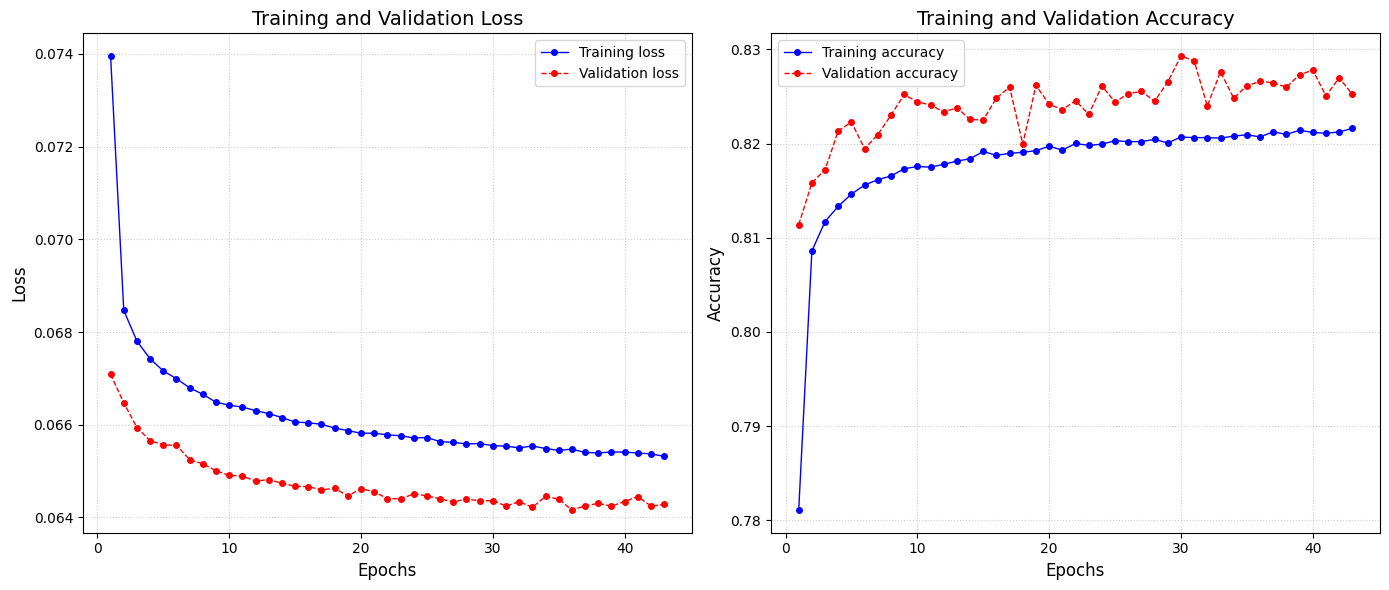

In [74]:
import matplotlib.pyplot as plt

# Récupération de l'historique d'entraînement
history_dict = keras_history.history

# Extraire les métriques
loss = history_dict['loss']
val_loss = history_dict['val_loss']
accuracy = history_dict['accuracy']
val_accuracy = history_dict['val_accuracy']

epochs = range(1, len(loss) + 1)

plt.figure(figsize=(14, 6))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, loss, 'bo-', label='Training loss', markersize=4, linewidth=1)
plt.plot(epochs, val_loss, 'ro--', label='Validation loss', markersize=4, linewidth=1)
plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, accuracy, 'bo-', label='Training accuracy', markersize=4, linewidth=1)
plt.plot(epochs, val_accuracy, 'ro--', label='Validation accuracy', markersize=4, linewidth=1)
plt.title('Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


#Courbes de performance

##Pour le score

In [75]:
import matplotlib.pyplot as plt
import numpy as np


def plot_score_separability(
    y_true, y_pred, sample_weights, plot_output_path="nn_day1_score_distribution.png"
):
    """
    Plots a normalized, weighted histogram overlay of the model scores
    separately for true Higgs Signal and Standard Model Background.
    """
    plt.figure(figsize=(8, 6))

    # Define 50 bins scanning the full scale of the Sigmoid output layer
    bins = np.linspace(0.0, 1.0, 50)

    # Draw Weighted Signal Histogram
    plt.hist(
        y_pred[y_true == 1],
        bins=bins,
        weights=sample_weights[y_true == 1],
        alpha=0.5,
        color="royalblue",
        label="True Higgs Signal ($H \\rightarrow \\tau\\tau$)",
        density=True,  # Normalizes area to 1 to compare shape shapes directly
    )

    # Draw Weighted Background Histogram
    plt.hist(
        y_pred[y_true == 0],
        bins=bins,
        weights=sample_weights[y_true == 0],
        alpha=0.5,
        color="crimson",
        label="Standard Model Background",
        density=True,
    )

    plt.xlim([0.0, 1.0])
    plt.xlabel("Neural Network Selection Score (Probability)")
    plt.ylabel("Normalized Event Density (Weighted)")
    plt.title("Day 1 Neural Network Score Separability Distribution")
    plt.legend(loc="upper center")
    plt.grid(True, linestyle="--", alpha=0.3)

    plt.tight_layout()
    plt.savefig(plot_output_path, dpi=300)
    plt.close()
    print("Physics diagnostic: Score distribution overlay plot generated successfully.")


##Pour la ROC

In [76]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import auc, roc_curve


def calculate_weighted_roc(
    y_true, y_pred, sample_weights, plot_output_path="nn_day1_roc_curve.png"
):
    """
    Computes the False Positive Rate, True Positive Rate, and AUC score
    using physical event weights, and plots the standard ROC curve.
    """
    # Compute the weighted ROC curve components
    fpr, tpr, thresholds = roc_curve(y_true, y_pred, sample_weight=sample_weights)
    auc_score = auc(fpr, tpr)

    print("-" * 40)
    print(f"ROC EVALUATION COMPLETED")
    print(f"Weighted ROC AUC Score: {auc_score:.4f}")
    print("-" * 40)

    # Generate the physics-standard ROC Plot
    plt.figure(figsize=(7, 6))
    plt.plot(
        fpr,
        tpr,
        color="darkorange",
        lw=2,
        label=f"NN Classifier (AUC = {auc_score:.4f})",
    )
    plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate (Background Efficiency)")
    plt.ylabel("True Positive Rate (Signal Efficiency)")
    plt.title("Weighted Receiver Operating Characteristic (ROC)")
    plt.legend(loc="lower right")
    plt.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.savefig(plot_output_path, dpi=300)
    plt.close()

    return fpr, tpr, auc_score


##Pour la significance

In [77]:
import matplotlib.pyplot as plt
import numpy as np


def optimize_poisson_significance(
    y_true,
    y_pred,
    sample_weights,
    step=0.01,
    plot_output_path="nn_day1_significance_scan.png",
):
    """
    Sweeps score cuts from 0.0 to 1.0 to find the optimal threshold
    maximizing s / sqrt(s + b) based on physical cross-section weights.
    """
    thresholds = np.arange(0.0, 1.0, step)
    significances = []
    s_yields = []
    b_yields = []

    signal_mask = y_true == 1
    background_mask = y_true == 0

    # Linearly scan the scores to evaluate threshold capabilities
    for t in thresholds:
        accepted_events = y_pred >= t

        # Aggregate physical counts for events passing the cut
        s = np.sum(sample_weights[signal_mask & accepted_events])
        b = np.sum(sample_weights[background_mask & accepted_events])

        # Compute standard Poisson significance approximation
        if (s + b) > 0:
            sig = s / np.sqrt(s + b)
        else:
            sig = 0.0

        significances.append(sig)
        s_yields.append(s)
        b_yields.append(b)

    significances = np.array(significances)

    # Locate the optimum working point
    max_idx = np.argmax(significances)
    optimal_threshold = thresholds[max_idx]
    max_significance = significances[max_idx]
    opt_s = s_yields[max_idx]
    opt_b = b_yields[max_idx]

    print("=" * 45)
    print("SIGNIFICANCE OPTIMIZATION COMPLETE")
    print(f"Max Significance:   {max_significance:.3f} sigma")
    print(f"Optimal Score Cut:  {optimal_threshold:.2f}")
    print(f"Yields at Cut:      Signal={opt_s:.2f}, Background={opt_b:.2f}")
    print("=" * 45)

    # Plot Significance Curve
    plt.figure(figsize=(7, 6))
    plt.plot(
        thresholds, significances, color="purple", lw=2, label="Significance Profile"
    )
    plt.axvline(
        x=optimal_threshold,
        color="black",
        linestyle=":",
        label=f"Optimal Working Cut ({optimal_threshold:.2f})",
    )

    plt.xlim([0.0, 1.0])
    plt.xlabel("Neural Network Selection Cut Threshold")
    plt.ylabel("Poisson Significance [s / sqrt(s+b)]")
    plt.title(f"Significance Scan Profile (Max: {max_significance:.3f} $\sigma$)")
    plt.legend(loc="upper right")
    plt.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.savefig(plot_output_path, dpi=300)
    plt.close()

    return optimal_threshold, max_significance


##Tracer les plots

1/3 - Calcul des prédictions sur l'ensemble de test...
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

2/3 - Génération des métriques et des graphiques physiques...
----------------------------------------
ROC EVALUATION COMPLETED
Weighted ROC AUC Score: 0.8805
----------------------------------------
Physics diagnostic: Score distribution overlay plot generated successfully.

3/3 - Calcul du seuil de sélection optimal...
SIGNIFICANCE OPTIMIZATION COMPLETE
Max Significance:   3.047 sigma
Optimal Score Cut:  0.93
Yields at Cut:      Signal=51.93, Background=238.59

📊 TABLEAU DE BORD DES PERFORMANCES :


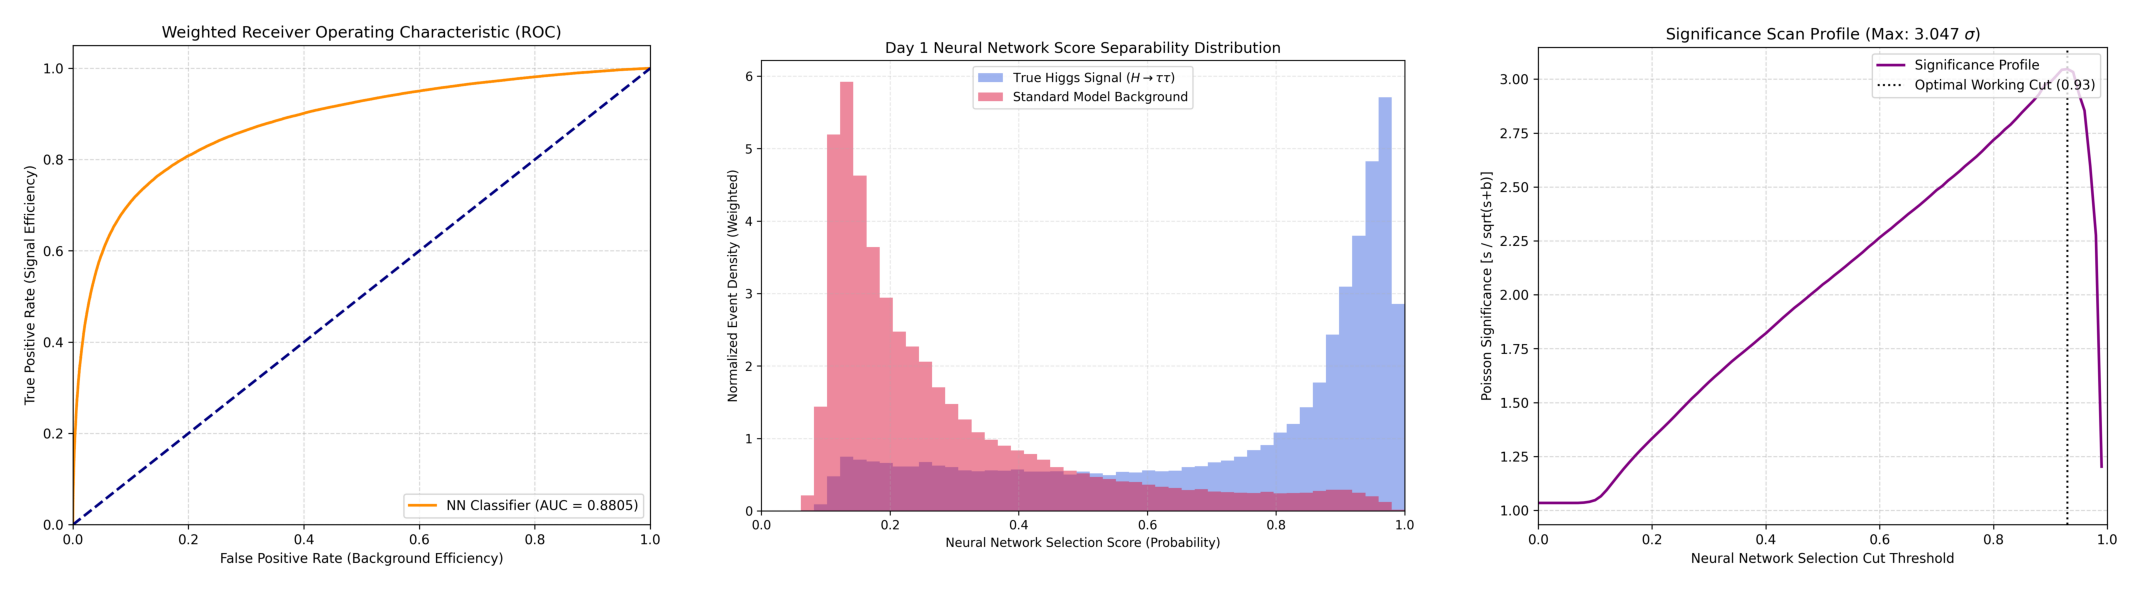

In [78]:
import cv2
import matplotlib.pyplot as plt


print("1/3 - Calcul des prédictions sur l'ensemble de test...")
predictions = nn.predict(X_test)

print("\n2/3 - Génération des métriques et des graphiques physiques...")
calculate_weighted_roc(y_test, predictions, sample_weights=w_test)
plot_score_separability(y_test, predictions, sample_weights=w_test)

print("\n3/3 - Calcul du seuil de sélection optimal...")
optimal_cut, max_sig = optimize_poisson_significance(
    y_test, predictions, sample_weights=w_test
)

# --- Affichage des diagnostics générés ---
print("\n📊 TABLEAU DE BORD DES PERFORMANCES :")
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

img_roc = cv2.imread("nn_day1_roc_curve.png")
axes[0].imshow(cv2.cvtColor(img_roc, cv2.COLOR_BGR2RGB))
axes[0].axis("off")

img_dist = cv2.imread("nn_day1_score_distribution.png")
axes[1].imshow(cv2.cvtColor(img_dist, cv2.COLOR_BGR2RGB))
axes[1].axis("off")

img_sig = cv2.imread("nn_day1_significance_scan.png")
axes[2].imshow(cv2.cvtColor(img_sig, cv2.COLOR_BGR2RGB))
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [79]:
import numpy as np

# Calculate the sum of weights for signal (y_test == 1) in the test set
signal_weights_sum_test = np.sum(w_test[y_test == 1])

# Calculate the sum of weights for background (y_test == 0) in the test set
background_weights_sum_test = np.sum(w_test[y_test == 0])

print(f"Sum of weights for Signal in Test set: {signal_weights_sum_test:.4f}")
print(f"Sum of weights for Background in Test set: {background_weights_sum_test:.4f}")

if np.isclose(signal_weights_sum_test, background_weights_sum_test):
    print("The sum of weights for Signal and Background in the Test set are approximately equal.")
else:
    print("The sum of weights for Signal and Background in the Test set are NOT equal.")

Sum of weights for Signal in Test set: 168.3143
Sum of weights for Background in Test set: 26311.6096
The sum of weights for Signal and Background in the Test set are NOT equal.


In [80]:
import numpy as np

# Calculate the sum of weights for signal (y_train == 1) in the training set
signal_weights_sum_train = np.sum(w_train[y_train == 1])

# Calculate the sum of weights for background (y_train == 0) in the training set
background_weights_sum_train = np.sum(w_train[y_train == 0])

print(f"Sum of weights for Signal in Training set: {signal_weights_sum_train:.4f}")
print(f"Sum of weights for Background in Training set: {background_weights_sum_train:.4f}")

if np.isclose(signal_weights_sum_train, background_weights_sum_train):
    print("The sum of weights for Signal and Background in the Training set are approximately equal.")
else:
    print("The sum of weights for Signal and Background in the Training set are NOT equal.")

Sum of weights for Signal in Training set: 62985.0210
Sum of weights for Background in Training set: 62985.0210
The sum of weights for Signal and Background in the Training set are approximately equal.
